In [36]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import pandas as pd
import os
from typing import Dict
import pickle
from scipy.stats import linregress
import ipywidgets as widgets
from IPython.display import display


def make_path_exist(filepath):
    os.makedirs(os.path.dirname(filepath), exist_ok=True)


def set_default_plot_style():
    plt.style.use("default")  # start clean

    plt.rcParams["axes.grid"] = True
    plt.rcParams["grid.alpha"] = 0.2
    plt.rcParams["grid.linestyle"] = "-"
    plt.rcParams["grid.color"] = "gray"

    plt.rcParams["axes.spines.top"] = False
    plt.rcParams["axes.spines.right"] = False

    plt.rcParams["axes.linewidth"] = 1.2

    plt.rcParams["legend.frameon"] = False

    plt.rcParams["font.size"] = 23
    plt.rcParams["axes.labelsize"] = 30
    plt.rcParams["legend.fontsize"] = 21

    mpl.rcParams['text.usetex'] = True
    mpl.rcParams['font.family'] = 'serif'
    mpl.rcParams['font.serif'] = ['Computer Modern Roman']

# Call once at the top of your script
set_default_plot_style()


In [37]:
# Helpful funcs
def log_b(x, b):
    return np.log(x) / np.log(b)


In [38]:
L_vals = [64, 128, 256, 512]
# L_vals = [1024]
# L_vals = [128, 256]
a_c = 0.75
a_vals = sorted(list(set([0.7579, 0.758, 0.7581, 0.7582])))
# a_vals = sorted([0.7569, 0.7589])
# a_vals = sorted([0.7599]) 
# a_vals = [0.7525]
# a_vals = sorted([0.75])
# a_vals = sorted([0.763, 0.7675, 0.77, 0.78, 0.79])
# a_vals = [0.78, 0.79]

N_val = 4

time_prefact = 100

num_initial_conds = 1000
num_init_conds_offset = 0

time_step = 100

cmap = plt.colormaps.get_cmap("Blues").resampled(len(L_vals) + 5)

read_external_drive = True
write_external_drive = read_external_drive and True
local_data_parent_folder = "../data"
second_data_parent_folder = "/Volumes/ExternalData/s_diff_per_time/"
if read_external_drive:
    data_parent_folder = "/Volumes/ExternalData/s_diff_per_time/"
    if write_external_drive:
        local_data_parent_folder = "/Volumes/ExternalData/s_diff_per_time/"      
        second_data_parent_folder = "../data/s_diff_per_time/"
else:
    data_parent_folder = local_data_parent_folder

# If first time

In [39]:


collected_sdiffs = {}
collected_sdiff_stds = {}

for L_val in L_vals:
    print(f"L_val: {L_val}")

    T_f = L_val*time_prefact
    collected_sdiffs[L_val] = {}
    collected_sdiff_stds[L_val] = {}

    collected_sdiffs[L_val] = {}
    collected_sdiff_stds[L_val] = {}

    for a_val in a_vals:
        print(f"L_val: {L_val} | a: {a_val}")
        a_val_name = f"{a_val}".replace(".", "p")

        current_sdiff = []
        for init_cond in range(1, num_initial_conds+1):
            sample_filepath_name = os.path.join(data_parent_folder, f"N{N_val}/a{a_val_name}/IC1/L{L_val}/N{N_val}_a{a_val_name}_IC1_L{L_val}_timepref{time_prefact}_timestep{time_step}_sample{init_cond}.csv")
                
            try:
                df = pd.read_csv(sample_filepath_name)

                current_sdiff.append(df.s_diff)
            except Exception as e:
                print(e)
                print(sample_filepath_name)
                
        current_sdiff = np.array(current_sdiff)
        collected_sdiffs[L_val][a_val] = np.mean(current_sdiff.T, axis=1)
        collected_sdiff_stds[L_val][a_val] = np.std(current_sdiff.T, axis=1)

        pickle_path = os.path.join(local_data_parent_folder, f"N{N_val}/a{a_val_name}/IC{num_initial_conds}/L{L_val}/N{N_val}_IC{num_initial_conds}_L{L_val}_a{a_val_name}_timepref{time_prefact}_timestep{time_step}")
        second_pickle_path = os.path.join(second_data_parent_folder, f"N{N_val}/a{a_val_name}/IC{num_initial_conds}/L{L_val}/N{N_val}_IC{num_initial_conds}_L{L_val}_a{a_val_name}_timepref{time_prefact}_timestep{time_step}")
                                                                
        dir_path = os.path.dirname(pickle_path)
        os.makedirs(dir_path, exist_ok=True)
        
        with open(pickle_path + "mean.pickle", "wb") as f:
            pickle.dump(collected_sdiffs[L_val][a_val], f)
        with open(pickle_path + "stds.pickle", "wb") as f:
            pickle.dump(collected_sdiff_stds[L_val][a_val], f)

        try:
            dir_path = os.path.dirname(second_pickle_path)
            os.makedirs(dir_path, exist_ok=True)
            with open(second_pickle_path + "mean.pickle", "wb") as f:
                pickle.dump(collected_sdiffs[L_val][a_val], f)
            with open(second_pickle_path + "stds.pickle", "wb") as f:
                pickle.dump(collected_sdiff_stds[L_val][a_val], f)
        except Exception as E:
            print(E)

L_val: 64
L_val: 64 | a: 0.7579
[Errno 2] No such file or directory: '/Volumes/ExternalData/s_diff_per_time/N4/a0p7579/IC1/L64/N4_a0p7579_IC1_L64_timepref100_timestep100_sample1.csv'
/Volumes/ExternalData/s_diff_per_time/N4/a0p7579/IC1/L64/N4_a0p7579_IC1_L64_timepref100_timestep100_sample1.csv
[Errno 2] No such file or directory: '/Volumes/ExternalData/s_diff_per_time/N4/a0p7579/IC1/L64/N4_a0p7579_IC1_L64_timepref100_timestep100_sample2.csv'
/Volumes/ExternalData/s_diff_per_time/N4/a0p7579/IC1/L64/N4_a0p7579_IC1_L64_timepref100_timestep100_sample2.csv
[Errno 2] No such file or directory: '/Volumes/ExternalData/s_diff_per_time/N4/a0p7579/IC1/L64/N4_a0p7579_IC1_L64_timepref100_timestep100_sample3.csv'
/Volumes/ExternalData/s_diff_per_time/N4/a0p7579/IC1/L64/N4_a0p7579_IC1_L64_timepref100_timestep100_sample3.csv
[Errno 2] No such file or directory: '/Volumes/ExternalData/s_diff_per_time/N4/a0p7579/IC1/L64/N4_a0p7579_IC1_L64_timepref100_timestep100_sample4.csv'
/Volumes/ExternalData/s_diff

AxisError: axis 1 is out of bounds for array of dimension 1

In [25]:
print(sample_filepath_name)

/Volumes/ExternalData/s_diff_per_time/N4/a0p7582/IC1/L512/N4_a0p7582_IC1_L512_timepref100_timestep100_sample1000.csv


## If you have already processed and saved the data as pickled

In [40]:

collected_sdiffs = {}
collected_sdiff_stds = {}

for L_val in L_vals:
    print(f"L_val: {L_val}")

    T_f = L_val*time_prefact
    collected_sdiffs[L_val] = {}
    collected_sdiff_stds[L_val] = {}

    collected_sdiffs[L_val] = {}
    collected_sdiff_stds[L_val] = {}
    for a_val in a_vals:
        a_val_name = f"{a_val}".replace(".", "p")
        try:
            pickle_path = os.path.join(local_data_parent_folder, f"N{N_val}/a{a_val_name}/IC{num_initial_conds}/L{L_val}/N{N_val}_IC{num_initial_conds}_L{L_val}_a{a_val_name}_timepref{time_prefact}_timestep{time_step}")

            with open(pickle_path + "mean.pickle", "rb") as f:
                collected_sdiffs[L_val][a_val] = pickle.load(f)
            with open(pickle_path + "stds.pickle", "rb") as f:
                collected_sdiff_stds[L_val][a_val] = pickle.load(f)

        except:
            pickle_path = os.path.join(second_data_parent_folder, f"N{N_val}/a{a_val_name}/IC{num_initial_conds}/L{L_val}/N{N_val}_IC{num_initial_conds}_L{L_val}_a{a_val_name}_timepref{time_prefact}_timestep{time_step}")

            with open(pickle_path + "mean.pickle", "rb") as f:
                collected_sdiffs[L_val][a_val] = pickle.load(f)
            with open(pickle_path + "stds.pickle", "rb") as f:
                collected_sdiff_stds[L_val][a_val] = pickle.load(f)

L_val: 64
L_val: 128
L_val: 256
L_val: 512


In [11]:
collected_sdiffs[L_vals[0]][a_vals[0]] == collected_sdiffs[L_vals[0]][a_vals[1]]

array([False, False, False, ..., False, False, False], shape=(5120,))

In [13]:
512**1.7

40342.1401364862

In [14]:
512*100

51200

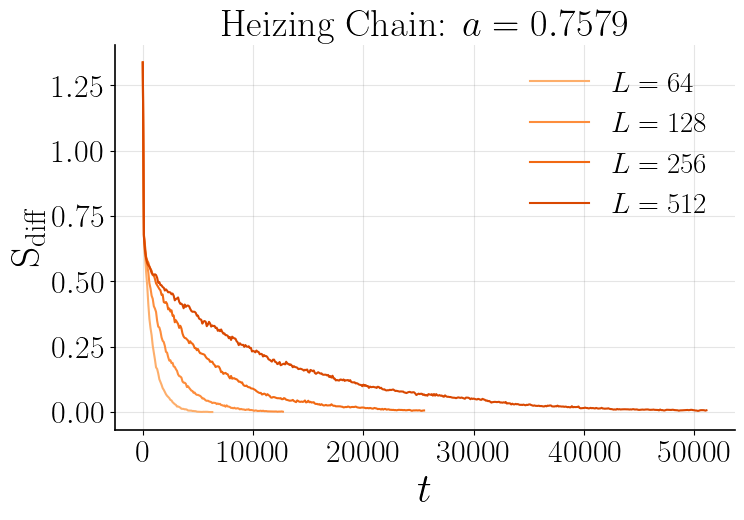

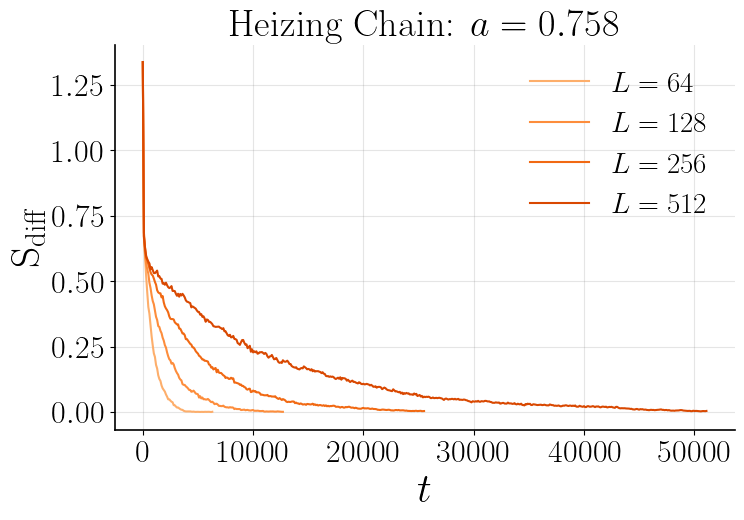

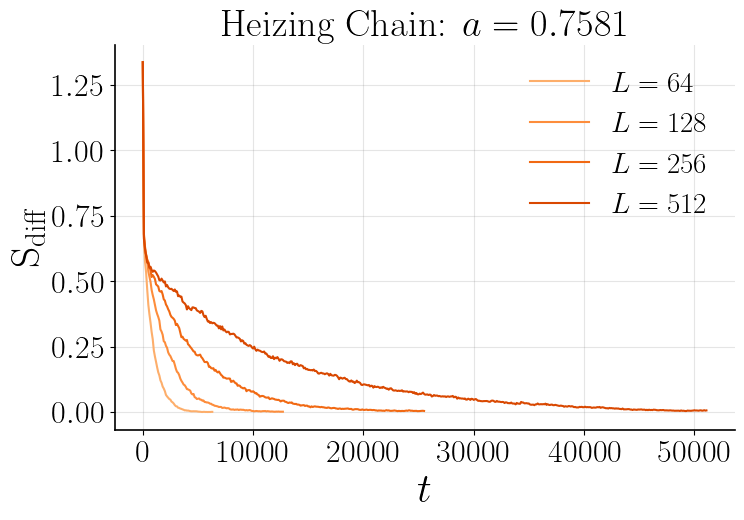

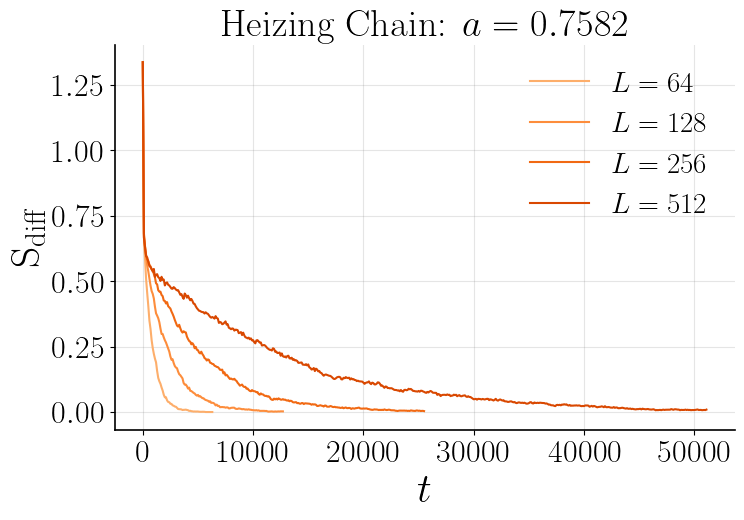

In [5]:

for i, a_val in enumerate(a_vals):
    plt.figure(figsize=(8,5))

    for j, L in enumerate(L_vals):
        c = cmap(j+3)
        time_vals = [k * time_step for k in range(0, L*time_prefact // time_step)][:]
        data_to_plot = collected_sdiffs[L][a_val]
        plt.plot(
            time_vals[:len(data_to_plot)], 
            (data_to_plot)[:], 
            label = fr"$L = {L}$",
            # fmt='--',  
            # markersize=3,
            # marker = "o",
            # capsize=3,
            c=c
            )
        
    # plt.axvline(0.29450750, c = 'k', label=f"x = 0.29450750 (old trans)")
    plt.title(fr"Heizing Chain: $a = {a_val}$")
    plt.xlabel(r"$t$")
    plt.ylabel(r"$\mathrm{S_{diff}}$")
    plt.legend()
    # plt.ylim(0.025, 0.325)

    plt.show()


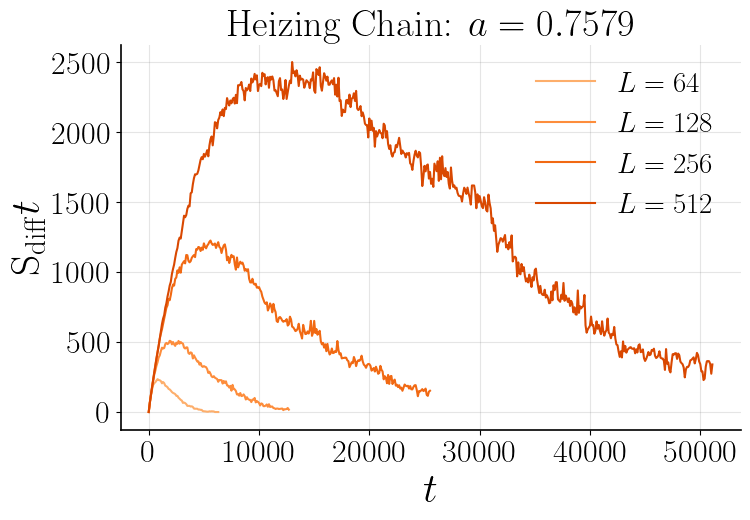

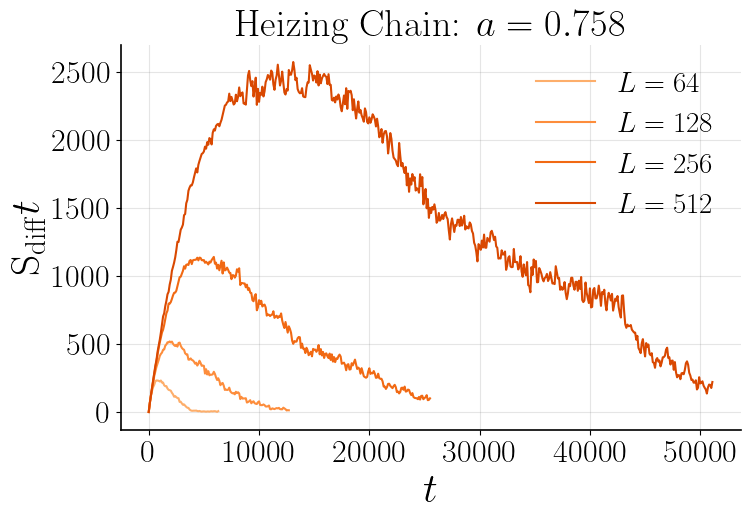

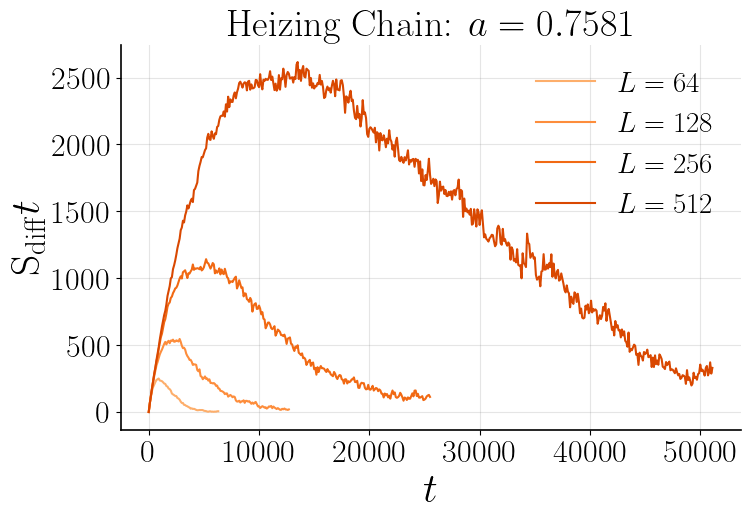

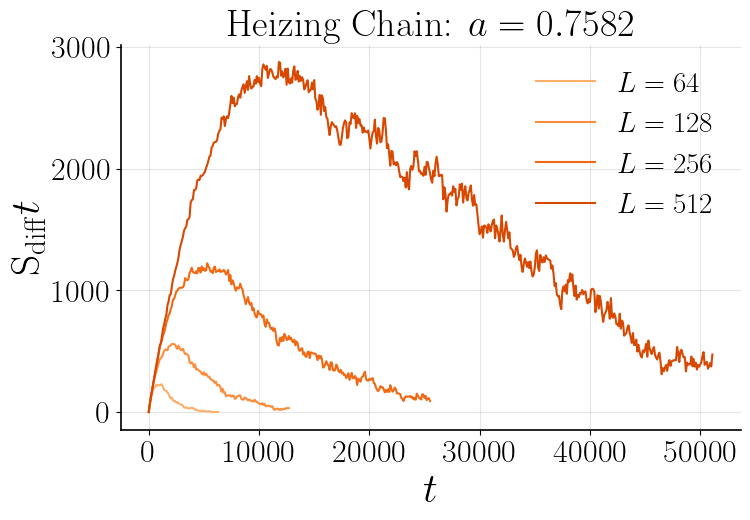

In [6]:

for i, a_val in enumerate(a_vals):
    plt.figure(figsize=(8,5))

    for j, L in enumerate(L_vals):
        c = cmap(j+3)
        time_vals = [k * time_step for k in range(0, L*time_prefact // time_step)][:]
        data_to_plot = collected_sdiffs[L][a_val]
        plt.plot(
            time_vals[:len(data_to_plot)], 
            (data_to_plot*time_vals)[:], 
            label = fr"$L = {L}$",
            # fmt='--',  
            # markersize=3,
            # marker = "o",
            # capsize=3,
            c=c
            )
        
    # plt.axvline(0.29450750, c = 'k', label=f"x = 0.29450750 (old trans)")
    plt.title(fr"Heizing Chain: $a = {a_val}$")
    plt.xlabel(r"$t$")
    plt.ylabel(r"$\mathrm{S_{diff}}t$")
    plt.legend()
    # plt.ylim(0.025, 0.325)

    plt.show()


/var/folders/0k/n4x5z88x1rx124p1g1l55hmc0000gn/T/ipykernel_36589/2725604191.py:8: RuntimeWarning: divide by zero encountered in log10
  np.log10(time_vals)[1:-10:],


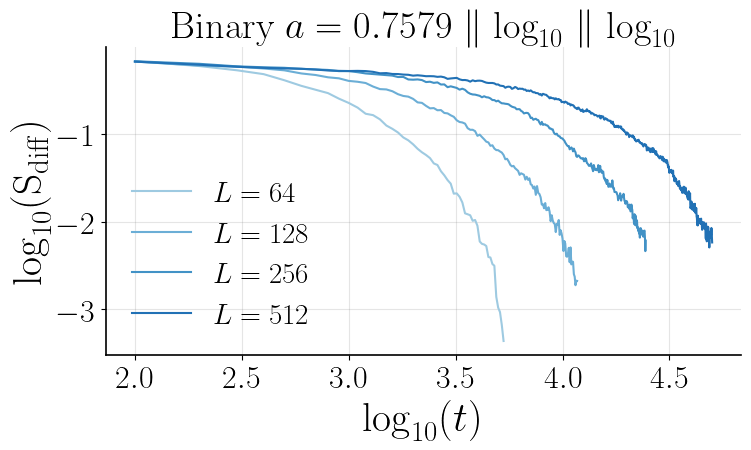

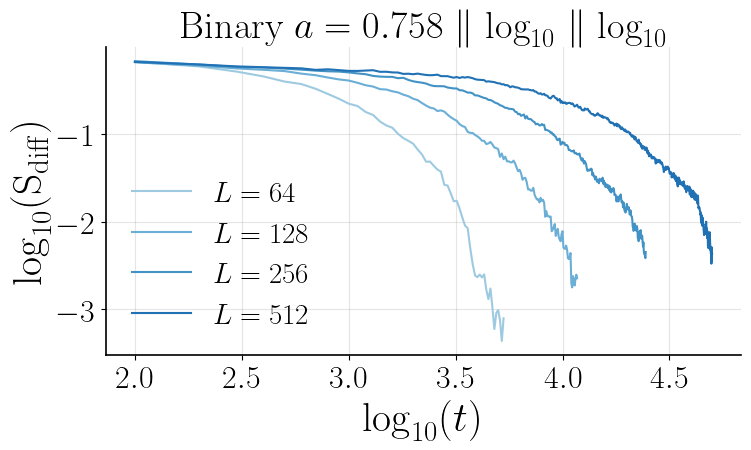

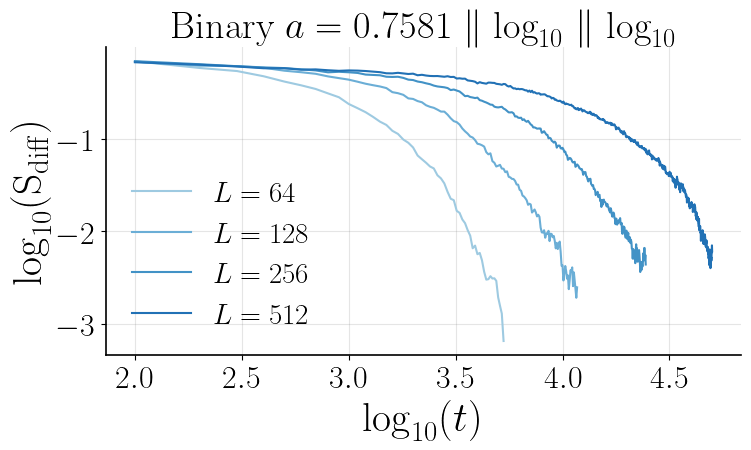

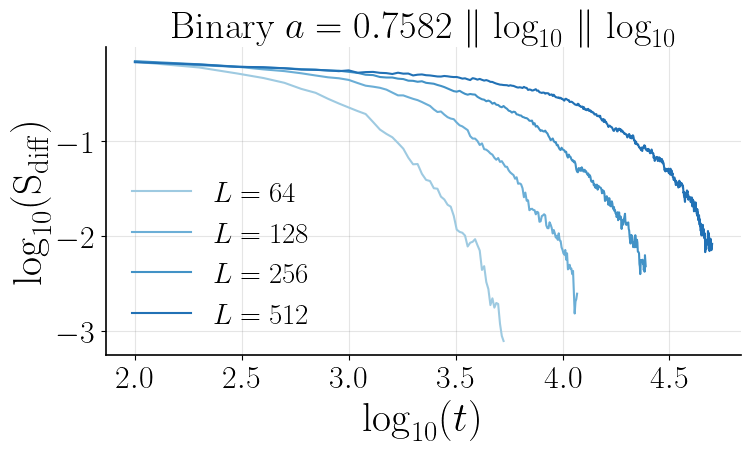

In [27]:

for i, a_val in enumerate(a_vals):
    plt.figure(figsize=(8,5))
    for j, L in enumerate(L_vals):
        c = cmap(j+3)
        time_vals = np.array([k * time_step for k in range(0, round(L*time_prefact / time_step))])
        orig_data = (collected_sdiffs[L][a_val])[0:len(time_vals)]
        plt.plot(
            np.log10(time_vals)[1:-10:], 
            np.log10((orig_data))[1:-10:], 
            label = fr"$L = {L}$",
            # fmt='--',  
            # markersize=3,
            # marker = "o",
            # capsize=3,
            c=c
            )

    # plt.axvline(0.29450750, c = 'k', label=f"x = 0.29450750 (old trans)")
    plt.title(fr"Binary $a={a_val}$ $\|$ $\log_{{10}}$ $\|$ $\log_{{10}}$")
    plt.xlabel(r"$\log_{10}(t)$")
    plt.ylabel(r"$\log_{10}(\mathrm{S_{diff}})$")
    plt.legend()
    # plt.xlim(np.log10(0.001), np.log10(1))
    # plt.ylim(0.7, 0.77)
    plt.tight_layout()
    # plt.savefig(f"figs/time_random/n_a{a_val_name}/z_estimate.png")

    plt.show()

In [11]:
a_vals

[0.7579, 0.758, 0.7581, 0.7582]

figs/time_random/spin_chain/a0p7579/spin_chain_determining_z1p25.png


/var/folders/0k/n4x5z88x1rx124p1g1l55hmc0000gn/T/ipykernel_36589/1929441888.py:24: RuntimeWarning: divide by zero encountered in log10
  np.log10(time_vals/(L**z))[1:-10],
/var/folders/0k/n4x5z88x1rx124p1g1l55hmc0000gn/T/ipykernel_36589/1929441888.py:25: RuntimeWarning: divide by zero encountered in log10
  np.log10(orig_data * time_vals**found_delta)[1:-10],


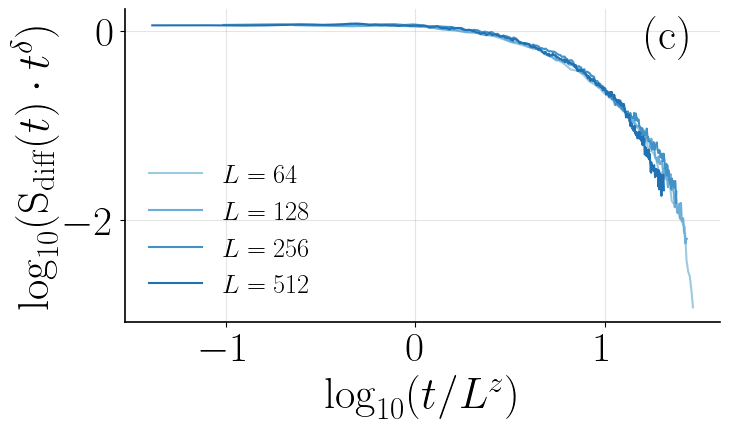

figs/time_random/spin_chain/a0p758/spin_chain_determining_z1p3.png


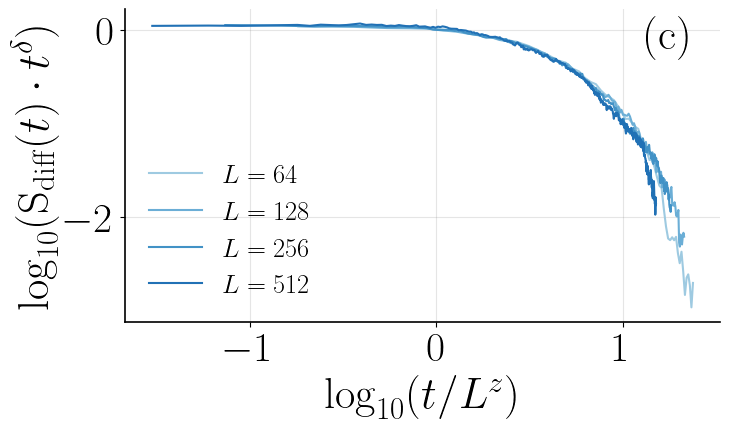

figs/time_random/spin_chain/a0p7581/spin_chain_determining_z1p3.png


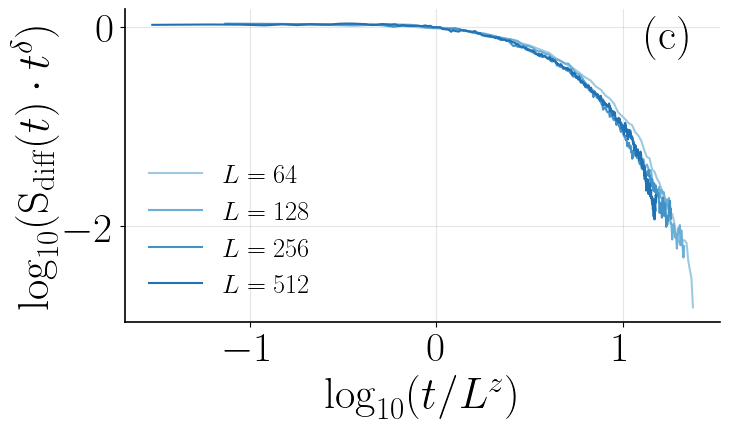

figs/time_random/spin_chain/a0p7582/spin_chain_determining_z1p3.png


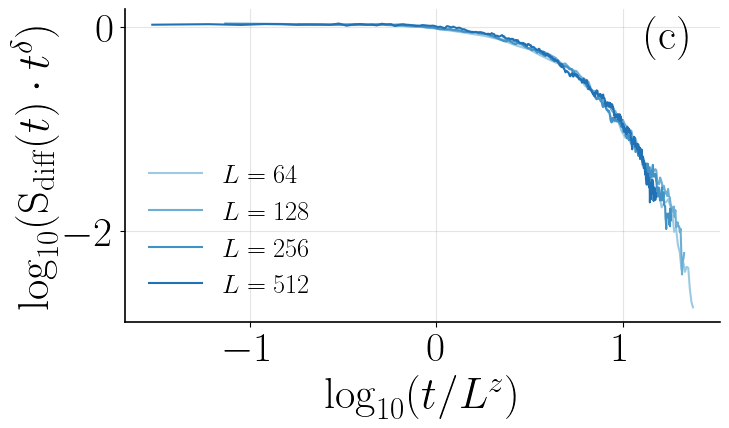

In [49]:
found_delta = 0.105
z_guesses = {0.7572:1.0, 0.75725: 1.0, 0.7574:1.0, 0.7575: 1.1, 0.7576:1.0, 0.75775: 1.2, 0.7578:1.3, 0.7579:1.25, 0.758:1.3, 0.7581:1.3, 0.7582:1.3}
delta_guesses = {0.7579: 0.1175, 0.758: 0.1075, 0.7581: 0.099, 0.7582: 0.0975}

# a_vals = [0.7579, 0.758, 0.7581, 0.7582]
a_vals = [0.7579, 0.758, 0.7581, 0.7582]

plt.rcParams["font.size"] = 30
plt.rcParams["axes.labelsize"] = 32
plt.rcParams["legend.fontsize"] = 19

for i, a_val in enumerate(a_vals):
    z = z_guesses[a_val]
    found_delta = delta_guesses[a_val]
    fig, ax = plt.subplots(figsize=(8, 5))

    for j, L in enumerate(L_vals):
        # if L == 1024:
        #     continue
        c = cmap(j + 3)
        time_vals = np.array([k * time_step for k in range(0, round(L * time_prefact / time_step))])
        orig_data = (collected_sdiffs[L][a_val])[0:len(time_vals)]
        ax.plot(
            np.log10(time_vals/(L**z))[1:-10],
            np.log10(orig_data * time_vals**found_delta)[1:-10],
            label=fr"$L = {L}$",
            c=c
        )

    # ax.set_title(fr"$a={a_val}$ $|$ $z={z:.4f}$ $|$ $\delta = {found_delta}$")
    ax.text(0.85, 0.83, "(c)", fontsize=plt.rcParams["axes.labelsize"], transform=fig.transFigure)
    ax.set_xlabel(r"$\log_{10}(t/L^z)$")
    ax.set_ylabel(r"$\log_{10}(\mathrm{S_{diff}}(t) \cdot t^\delta)$")
    ax.legend()
    fig.tight_layout()

    file_path = f"figs/time_random/spin_chain/a{str(a_val).replace(".", "p")}/spin_chain_determining_z{str(z).replace(".", "p")}.png"
    make_path_exist(file_path)
    fig.tight_layout()
    plt.savefig(file_path)
    print(file_path)
    plt.show()

figs/time_random/spin_chain/a0p7579/spin_chain_determining_z1p25.png


/var/folders/0k/n4x5z88x1rx124p1g1l55hmc0000gn/T/ipykernel_36589/3051615867.py:16: RuntimeWarning: divide by zero encountered in log10
  np.log10(time_vals)[1:-10],
/var/folders/0k/n4x5z88x1rx124p1g1l55hmc0000gn/T/ipykernel_36589/3051615867.py:24: RuntimeWarning: divide by zero encountered in log10
  np.log10(time_vals**(1/z) / (L))[1:-10],
/var/folders/0k/n4x5z88x1rx124p1g1l55hmc0000gn/T/ipykernel_36589/3051615867.py:25: RuntimeWarning: divide by zero encountered in log10
  np.log10(orig_data * time_vals**found_delta)[1:-10],


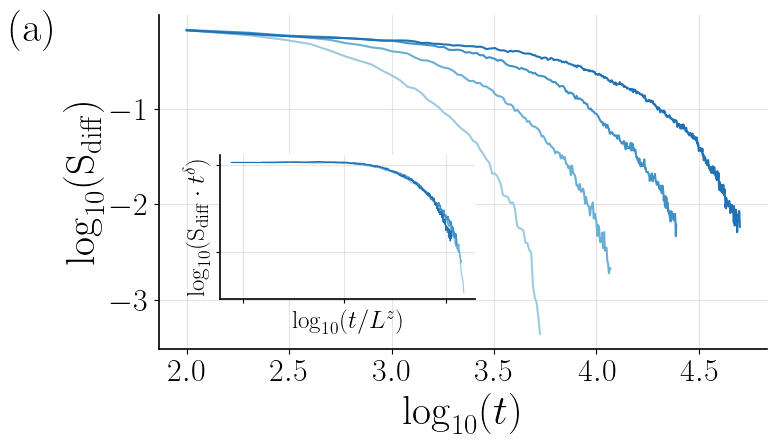

figs/time_random/spin_chain/a0p758/spin_chain_determining_z1p3.png


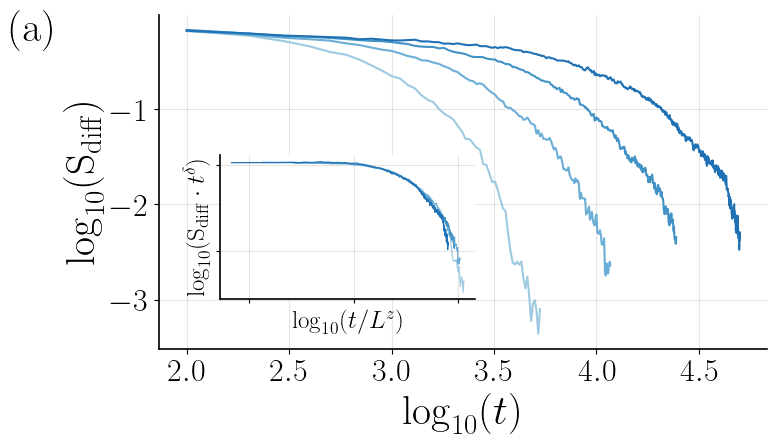

figs/time_random/spin_chain/a0p7581/spin_chain_determining_z1p3.png


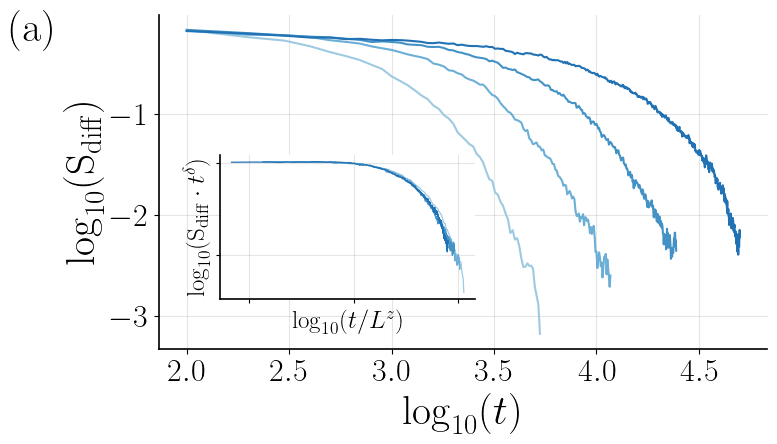

figs/time_random/spin_chain/a0p7582/spin_chain_determining_z1p3.png


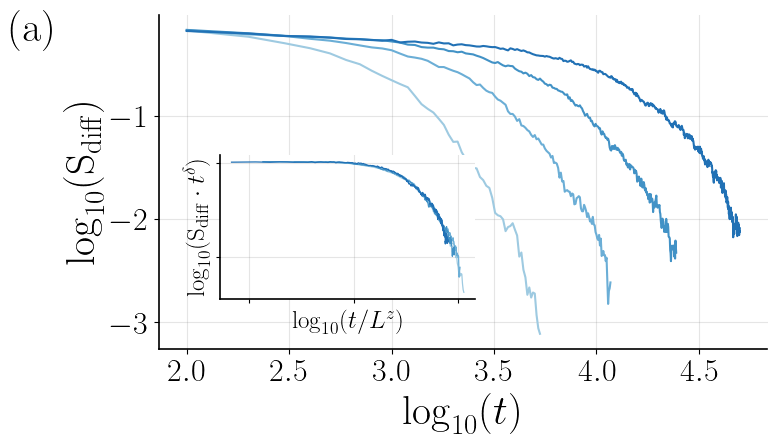

In [ ]:

for i, a_val in enumerate(a_vals):
    z = z_guesses[a_val]
    found_delta = delta_guesses[a_val]
    fig, ax = plt.subplots(figsize=(8, 5))

    # --- Inset axes (collapsed data) ---
    ax_inset = ax.inset_axes([0.1, 0.15, 0.42, 0.43])  # [x0, y0, width, height] in axes coords

    for j, L in enumerate(L_vals):
        c = cmap(j + 3)
        time_vals = np.array([k * time_step for k in range(0, round(L * time_prefact / time_step))])
        orig_data = (collected_sdiffs[L][a_val])[0:len(time_vals)]

        # Main raw data plot
        ax.plot(
            np.log10(time_vals)[1:-10],
            np.log10(orig_data)[1:-10],
            label=fr"$L = {L}$",
            c=c
        )

        # Inset collapse plot
        ax_inset.plot(
            np.log10(time_vals / (L**z))[1:-10],
            np.log10(orig_data * time_vals**found_delta)[1:-10],
            c=c,
            lw=0.9
        )

    # --- Inset formatting ---
    ax_inset.set_xlabel(r"$\log_{10}(t/L^z)$", fontsize=18)
    ax_inset.set_ylabel(r"$\log_{10}(\mathrm{S_{diff}} \cdot t^\delta)$", fontsize=18)
    ax_inset.tick_params(labelbottom=False, labelleft=False, length=3)
    ax_inset.set_facecolor(fig.get_facecolor())

    # --- Main axes formatting ---
    ax.text(0.01, 0.855, "(a)", fontsize=plt.rcParams["axes.labelsize"], transform=fig.transFigure)
    ax.set_xlabel(r"$\log_{10}(t)$")
    ax.set_ylabel(r"$\log_{10}(\mathrm{S_{diff}})$")
    # ax.legend(loc="lower left")
    fig.tight_layout()

    file_path = f"figs/time_random/spin_chain/a{str(a_val).replace('.', 'p')}/spin_chain_determining_z{str(z).replace('.', 'p')}.png"
    make_path_exist(file_path)
    fig.tight_layout()
    plt.savefig(file_path)
    print(file_path)
    plt.show()